<a href="https://colab.research.google.com/github/zmzain/zmzain/blob/main/1D_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 28.8 MB/s eta 0:00:00


[I 2026-05-24 08:44:54,845] A new study created in memory with name: no-name-0a0c5a21-96d1-4004-b661-1493b7f68ed0
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
[I 2026-05-24 08:45:12,489] Trial 0 finished with value: 0.69880359224942 and parameters: {'embedding_dim': 100, 'filters': 128, 'kernel_size': 7, 'dropout_rate': 0.3228897791507804, 'lr': 0.00015692619080149783, 'batch_size': 32}. Best is trial 0 with value: 0.69880359224942.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
[I 2026-05-24 08:45:29,928] Trial 1 finished with value: 0.7252647890374777 and parameters: {'embedding_dim': 64, 'filters': 512, 'kernel_size': 5, 'dropout_rate': 0.42491334857047836, 'lr': 0.0002010928981690187, 'batch_size': 32}. Best is trial 1 with value: 0.725264789037477

Best Params: {'embedding_dim': 200, 'filters': 128, 'kernel_size': 5, 'dropout_rate': 0.34181773154129313, 'lr': 0.0002571032118159435, 'batch_size': 64}
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


260/260 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.5550 - loss: 0.9874 - val_accuracy: 0.4967 - val_loss: 0.9126
Epoch 2/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7586 - loss: 0.6750 - val_accuracy: 0.7473 - val_loss: 0.6260
Epoch 3/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9017 - loss: 0.3080 - val_accuracy: 0.7614 - val_loss: 0.6236
Epoch 4/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9722 - loss: 0.1079 - val_accuracy: 0.7570 - val_loss: 0.7275
Epoch 5/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9916 - loss: 0.0421 - val_accuracy: 0.7495 - val_loss: 0.8332
Epoch 6/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9968 - loss: 0.0188 - val_accuracy: 0.7478 - val_loss: 0.9188
Epoch 7/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9981 - loss: 0.0107 - val_accuracy: 0.7500 - val_loss: 1.0186
Epoch 8/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9987 - loss: 0.0074 - val_accuracy: 0.7435 - va

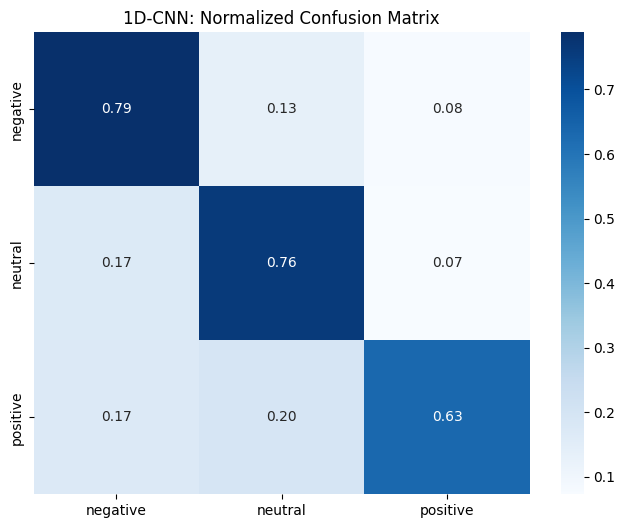

In [4]:
import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load and prepare data
# -----------------------------
df = pd.read_csv("https://raw.githubusercontent.com/zmzain/zmzain/89462097da8cf598cf5e1ddfc2853c4a088f3d49/data1.csv")
texts = df["Text"].astype(str).values
labels = df["class"].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)
num_classes = len(label_encoder.classes_)

max_words = 20000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
X_seq = tokenizer.texts_to_sequences(texts)
X_pad = pad_sequences(X_seq, maxlen=max_len, padding="post", truncating="post")
vocab_size = min(max_words, len(tokenizer.word_index) + 1)

X_train_pad, X_test_pad, y_train, y_test = train_test_split(
    X_pad, y, test_size=0.2, random_state=42, stratify=y
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_pad, y_train, test_size=0.2, random_state=42, stratify=y_train
)

classes = np.unique(y_tr)
class_weights_array = compute_class_weight("balanced", classes=classes, y=y_tr)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_array)}

# -----------------------------
# 2. 1D-CNN Model Builder
# -----------------------------
def build_cnn_model(trial, vocab_size, max_len, num_classes):
    # Hyperparameters
    embedding_dim = trial.suggest_categorical("embedding_dim", [64, 100, 200, 300])
    filters       = trial.suggest_categorical("filters", [96, 128, 256, 512])
    kernel_size   = trial.suggest_int("kernel_size", 3, 7) # Looks at 3-word to 7-word windows
    dropout_rate  = trial.suggest_float("dropout_rate", 0.3, 0.5)
    lr            = trial.suggest_float("lr", 1e-4, 1e-3, log=True)

    model = Sequential([
        Embedding(input_dim=vocab_size,
                  output_dim=embedding_dim,
                  input_length=max_len),

        # CNN Layer
        Conv1D(filters=filters, kernel_size=kernel_size, activation="relu", padding="same"),

        # Global Max Pooling is standard for CNN classification
        GlobalMaxPooling1D(),

        #BatchNormalization(),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=Adam(learning_rate=lr),
        metrics=["accuracy"]
    )
    return model

# -----------------------------
# 3. Optuna objective
# -----------------------------
def objective(trial):
    tf.keras.backend.clear_session()
    model = build_cnn_model(trial, vocab_size, max_len, num_classes)

    # CNNs train fast, so we can use a higher trial count or more epochs
    early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=batch_size,
        callbacks=[early_stop],
        class_weight=class_weights,
        verbose=0
    )

    y_val_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    return f1_score(y_val, y_val_pred, average="macro")

# -----------------------------
# 4. Run Optuna study
# -----------------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print(f"Best Params: {study.best_params}")

# -----------------------------
# 5. Train Final Model
# -----------------------------
tf.keras.backend.clear_session()
best_model = build_cnn_model(
    optuna.trial.FixedTrial(study.best_params),
    vocab_size, max_len, num_classes
)

best_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=study.best_params["batch_size"],
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    class_weight=class_weights,
    verbose=1
)

# -----------------------------
# 6. Final Evaluation
# -----------------------------
y_test_pred = np.argmax(best_model.predict(X_test_pad), axis=1)
print("\n--- 1D-CNN TEST REPORT ---")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))
p, r, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average="macro", zero_division=0)
print(f"Macro Precision: {p:.4f}")
print(f"Macro Recall:    {r:.4f}")
print(f"Macro F1-score:  {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("1D-CNN: Normalized Confusion Matrix")
plt.show()
